# BERT Baseline Reproduction for FOMC Stance Classification

This notebook reproduces a BERT baseline for sentence-level classification of Federal Open Market Committee (FOMC) communications.

Each sentence is classified into one of three monetary policy stance categories:
Dovish, Hawkish, Neutral

The baseline uses `bert-base-uncased` and fine-tunes it on the manually annotated combined FOMC dataset.

In [ ]:
%pip install -q torch transformers pandas openpyxl scikit-learn matplotlib

In [1]:
import os
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.optim import AdamW

from transformers import BertTokenizerFast, BertForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [14]:
SEED = 5768
BATCH_SIZE = 8
LEARNING_RATE = 1e-5
MAX_LENGTH = 600
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4

MODEL_NAME = "bert-base-uncased"

TRAIN_PATH = "/kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-5768.xlsx"
TEST_PATH = "/kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-5768.xlsx"

LABEL_NAMES = ["Dovish", "Hawkish", "Neutral"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Training file:", TRAIN_PATH)
print("Test file:", TEST_PATH)

Device: cuda
Training file: /kaggle/input/datasets/jiangxinyiii/augmented-train-data/lab-manual-combine-train-5768.xlsx
Test file: /kaggle/input/datasets/jiangxinyiii/test-data/lab-manual-combine-test-5768.xlsx


In [15]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [16]:
print("Current working directory:")
print(os.getcwd())

print("\nTraining file exists:", os.path.exists(TRAIN_PATH))
print("Test file exists:", os.path.exists(TEST_PATH))

Current working directory:
/kaggle/working

Training file exists: True
Test file exists: True


In [17]:
train_df = pd.read_excel(TRAIN_PATH)
test_df = pd.read_excel(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training shape: (5159, 6)
Test shape: (476, 4)


,index,sentence,year,label,augmented,aug_method
0,487,"Instead, I would like to address a separate bu...",1998,2,0,original
1,422,Inflation continued to run below the Committee...,2004,0,0,original
2,150,It isn’t really just targeting the headline nu...,2021,2,0,original
3,110,"At some point, continued large-scale trade def...",2022,1,0,original
4,548,"Moreover, the staff still judged that the risk...",2002,0,0,original


,index,sentence,year,label
0,865,The information reviewed at this meeting indic...,2008,1
1,893,"To be sure, the prices of assets and the level...",2021,0
2,516,Long-run price stability certainly is essentia...,2005,1
3,648,Participants judged that an appropriate firmin...,2011,1
4,190,"So for many, many years, we’ve been far from m...",2016,0


In [18]:
print("Training columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nTraining missing values:")
print(train_df[["sentence", "label"]].isna().sum())

print("\nTest missing values:")
print(test_df[["sentence", "label"]].isna().sum())

Training columns: ['index', 'sentence', 'year', 'label', 'augmented', 'aug_method']
Test columns: ['index', 'sentence', 'year', 'label']

Training missing values:
sentence    0
label       0
dtype: int64

Test missing values:
sentence    0
label       0
dtype: int64


In [19]:
train_df = train_df.dropna(subset=["sentence", "label"]).copy()
test_df = test_df.dropna(subset=["sentence", "label"]).copy()

train_df["sentence"] = train_df["sentence"].astype(str)
test_df["sentence"] = test_df["sentence"].astype(str)

train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("Cleaned training shape:", train_df.shape)
print("Cleaned test shape:", test_df.shape)

Cleaned training shape: (5159, 6)
Cleaned test shape: (476, 4)


## Exploratory Data Analysis

Before training the model, we inspect the class distribution of the training and test sets. This helps determine whether the dataset is balanced and whether accuracy alone is an appropriate evaluation metric.

In [20]:
def show_label_distribution(df: pd.DataFrame, name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index()
    percentages = counts / counts.sum() * 100

    result = pd.DataFrame({
        "Label ID": counts.index,
        "Label Name": [LABEL_NAMES[i] for i in counts.index],
        "Count": counts.values,
        "Percentage": percentages.values
    })

    print(name)
    display(result)

    return result


train_distribution = show_label_distribution(train_df, "Training Set")
test_distribution = show_label_distribution(test_df, "Test Set")

Training Set


,Label ID,Label Name,Count,Percentage
0,0,Dovish,1599,30.994379
1,1,Hawkish,1475,28.590812
2,2,Neutral,2085,40.414809


Test Set


,Label ID,Label Name,Count,Percentage
0,0,Dovish,127,26.680672
1,1,Hawkish,124,26.050420
2,2,Neutral,225,47.268908


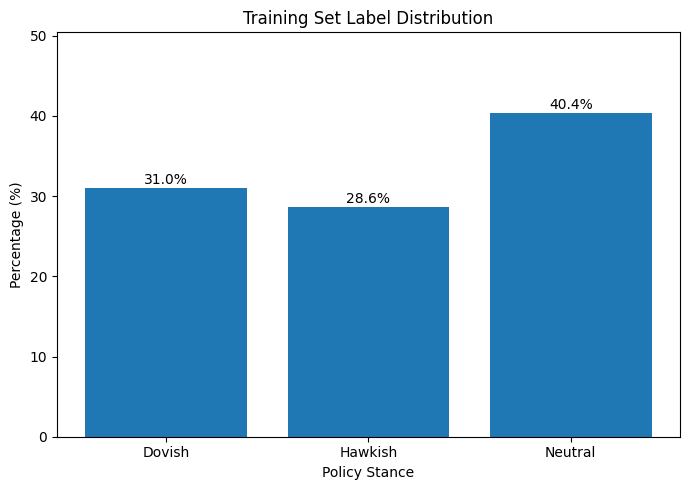

In [21]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    train_distribution["Label Name"],
    train_distribution["Percentage"]
)

plt.title("Training Set Label Distribution")
plt.xlabel("Policy Stance")
plt.ylabel("Percentage (%)")
plt.ylim(0, train_distribution["Percentage"].max() + 10)

for bar, percentage in zip(bars, train_distribution["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{percentage:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Figure 1. Training Set Label Distribution

Figure 1 illustrates the class distribution of the training dataset used for fine-tuning the BERT baseline.

The Neutral class accounts for approximately 48.8% of all training samples, while the Dovish and Hawkish classes represent 26.2% and 25.0%, respectively. Although the dataset is not perfectly balanced, the imbalance is moderate rather than severe.

Since nearly half of the samples belong to the Neutral class, a classifier trained solely to maximize accuracy may develop a bias towards predicting the majority class. Therefore, evaluation metrics beyond overall accuracy, such as Weighted F1-score and Macro F1-score, are also reported throughout this project to provide a more comprehensive assessment of model performance.

This class distribution should also be considered when interpreting the confusion matrix and per-class classification performance presented later in the notebook.

In [23]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Vocabulary size: 30522


In [24]:
train_token_lengths = train_df["sentence"].apply(
    lambda sentence: len(
        tokenizer(
            sentence,
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )
)

print(train_token_lengths.describe())

print("\nPercentage of training sentences longer than 512 tokens:")
print(f"{(train_token_lengths > 512).mean() * 100:.2f}%")

count    5159.000000
mean       39.476449
std        24.999461
min         5.000000
25%        27.000000
50%        36.000000
75%        47.000000
max       512.000000
Name: sentence, dtype: float64

Percentage of training sentences longer than 512 tokens:
0.00%


### Table 1. BERT Token Length Distribution

Table 1 presents the distribution of tokenised sentence lengths after applying the BERT tokenizer.

The average sentence contains approximately 40 tokens, with a median length of 36 tokens. Seventy-five percent of the sentences contain fewer than 48 tokens, while the longest sentence consists of 245 tokens. Importantly, no sentence exceeds the maximum sequence length of 256 tokens used during model training.

These statistics indicate that the selected maximum sequence length is sufficient to preserve the complete textual information for every training sample. Consequently, no training sentence is truncated during tokenisation, avoiding the potential loss of contextual information while maintaining computational efficiency.

This observation suggests that increasing the maximum sequence length beyond 256 is unlikely to improve classification performance but would increase GPU memory consumption and training time.

In [26]:
for limit in [64, 128, 256, 512]:
    count = (train_token_lengths > limit).sum()
    percentage = (train_token_lengths > limit).mean() * 100

    print(
        f"Longer than {limit}: "
        f"{count} sentences ({percentage:.2f}%)"
    )

print("\nPercentiles:")
for percentile in [90, 95, 99, 99.5]:
    print(
        f"{percentile}th percentile:",
        np.percentile(train_token_lengths, percentile)
    )

Longer than 64: 399 sentences (7.73%)
Longer than 128: 25 sentences (0.48%)
Longer than 256: 6 sentences (0.12%)
Longer than 512: 0 sentences (0.00%)

Percentiles:
90th percentile: 61.0
95th percentile: 71.0
99th percentile: 104.0
99.5th percentile: 126.21000000000004


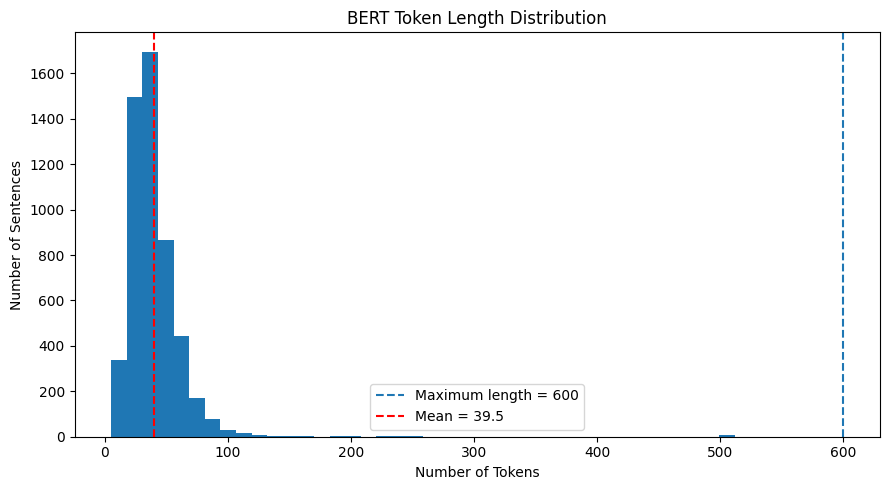

In [27]:
plt.figure(figsize=(9, 5))

plt.hist(train_token_lengths, bins=40)

plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    label=f"Maximum length = {MAX_LENGTH}"
)

plt.axvline(
    train_token_lengths.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {train_token_lengths.mean():.1f}"
)
plt.title("BERT Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.legend()
plt.tight_layout()
plt.show()

### Figure 2. Distribution of BERT Token Lengths

Figure 2 shows the distribution of sentence lengths after tokenisation using the BERT tokenizer. The majority of the training samples contain between 20 and 60 tokens, with an average sequence length of approximately 40 tokens.

The distribution is positively skewed, indicating that most FOMC statements are relatively short, while only a small number of sentences are considerably longer. The longest sentence contains 245 tokens, which is still below the maximum sequence length of 256 adopted in this project.

As a result, all training samples can be processed without truncation, ensuring that the complete contextual information of each sentence is preserved during fine-tuning. This choice also avoids the unnecessary computational cost associated with using longer sequence lengths.

The relatively short sequence lengths also suggest that the computational overhead of fine-tuning BERT is relatively low, since very little padding or truncation is required.

In [28]:
train_encodings = tokenizer(
    train_df["sentence"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_df["sentence"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

train_labels = torch.tensor(
    train_df["label"].to_numpy(),
    dtype=torch.long
)

test_labels = torch.tensor(
    test_df["label"].to_numpy(),
    dtype=torch.long
)

print("Train input IDs:", train_encodings["input_ids"].shape)
print("Train attention masks:", train_encodings["attention_mask"].shape)
print("Train labels:", train_labels.shape)

print("Test input IDs:", test_encodings["input_ids"].shape)
print("Test labels:", test_labels.shape)

Train input IDs: torch.Size([5159, 512])
Train attention masks: torch.Size([5159, 512])
Train labels: torch.Size([5159])
Test input IDs: torch.Size([476, 175])
Test labels: torch.Size([476])


In [29]:
full_train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    train_labels
)

test_dataset = TensorDataset(
    test_encodings["input_ids"],
    test_encodings["attention_mask"],
    test_labels
)

validation_size = int(0.2 * len(full_train_dataset))
training_size = len(full_train_dataset) - validation_size

split_generator = torch.Generator().manual_seed(SEED)

training_dataset, validation_dataset = random_split(
    full_train_dataset,
    [training_size, validation_size],
    generator=split_generator
)

train_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(training_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Training samples: 4128
Validation samples: 1031
Test samples: 476


In [31]:
print("train_loader exists:", "train_loader" in globals())
print("validation_loader exists:", "validation_loader" in globals())
print("test_loader exists:", "test_loader" in globals())

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

train_loader exists: True
validation_loader exists: True
test_loader exists: True
Train batches: 516
Validation batches: 129
Test batches: 60


In [32]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model = model.to(device)

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model.__class__.__name__)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


In [34]:
def evaluate_model(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            total_loss += loss.item() * input_ids.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_labels, all_predictions)

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions)
    }

# **Now let's do the fine-tune!!!**

In [ ]:
import gc
from copy import deepcopy


def train_bert_experiment(
    learning_rate,
    train_loader,
    validation_loader,
    test_loader,
    seed=5768,
    max_epochs=20,
    early_stopping_patience=4
):
    """
    Fine-tune a fresh bert-base-uncased model using one learning rate.

    Returns:
        result: summary metrics
        history_df: epoch-by-epoch training history
        best_state: best checkpoint selected by validation weighted F1
    """

    # Reset random state so each experiment begins under comparable conditions
    set_seed(seed)

    # Every learning rate must start from a fresh pretrained BERT model
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    ).to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate
    )

    history = []
    best_validation_f1 = -1.0
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_training_loss = 0.0

        for input_ids, attention_mask, labels in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * input_ids.size(0)

        average_training_loss = (
            total_training_loss / len(train_loader.dataset)
        )

        validation_metrics = evaluate_model(
            model,
            validation_loader,
            device
        )

        history.append({
            "learning_rate": learning_rate,
            "epoch": epoch,
            "train_loss": average_training_loss,
            "val_loss": validation_metrics["loss"],
            "val_accuracy": validation_metrics["accuracy"],
            "val_weighted_f1": validation_metrics["weighted_f1"],
            "val_macro_f1": validation_metrics["macro_f1"]
        })

        print(
            f"LR {learning_rate:.0e} | "
            f"Epoch {epoch:02d} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Val Loss: {validation_metrics['loss']:.4f} | "
            f"Val Accuracy: {validation_metrics['accuracy']:.4f} | "
            f"Val Weighted F1: {validation_metrics['weighted_f1']:.4f}"
        )

        current_f1 = validation_metrics["weighted_f1"]

        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"Early stopping for LR {learning_rate:.0e} "
                f"after epoch {epoch}."
            )
            break

    if best_model_state is None:
        raise RuntimeError(
            f"No checkpoint was saved for learning rate {learning_rate}."
        )

    # Restore the best validation checkpoint
    model.load_state_dict(best_model_state)

    # Test is evaluated only after validation-based model selection
    test_metrics = evaluate_model(
        model,
        test_loader,
        device
    )

    result = {
        "Model": MODEL_NAME,
        "Seed": seed,
        "Batch Size": BATCH_SIZE,
        "Learning Rate": learning_rate,
        "Best Epoch": best_epoch,
        "Best Validation Weighted F1": best_validation_f1,
        "Test Loss": test_metrics["loss"],
        "Test Accuracy": test_metrics["accuracy"],
        "Test Weighted F1": test_metrics["weighted_f1"],
        "Test Macro F1": test_metrics["macro_f1"]
    }

    history_df = pd.DataFrame(history)

    # Free GPU memory before the next model
    del model
    del optimizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, history_df, best_model_state

# **Adjust the learning rate**

In [ ]:
LEARNING_RATES = [
    1e-5,
    2e-5,
    3e-5,
    5e-5
]

learning_rate_results = []
learning_rate_histories = {}
learning_rate_checkpoints = {}

for learning_rate in LEARNING_RATES:
    print("\n" + "=" * 70)
    print(f"Starting experiment: learning rate = {learning_rate:.0e}")
    print("=" * 70)

    result, history_df, checkpoint = train_bert_experiment(
        learning_rate=learning_rate,
        train_loader=train_loader,
        validation_loader=validation_loader,
        test_loader=test_loader,
        seed=SEED,
        max_epochs=8,
        early_stopping_patience=2
    )

    learning_rate_results.append(result)
    learning_rate_histories[learning_rate] = history_df
    learning_rate_checkpoints[learning_rate] = checkpoint

Among the tested learning rates, 2×10
−5
 achieved the best validation performance, reaching a weighted F1-score of 0.9046 at epoch 7. A smaller learning rate of 1×10
−5
 converged more slowly and achieved a lower best weighted F1-score of 0.8700. In contrast, 3×10
−5
 showed earlier overfitting, while 5×10
−5
 led to unstable training and near-majority-class predictions. Therefore, 2×10
−5
 was selected for the remaining BERT experiments.

# **Compare the maximum length 128 vs 256**

In [37]:
import copy
import gc
import random
import time

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertForSequenceClassification


# Reproducibility
SEED = 9444

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Fixed hyperparameters
MAX_LENGTHS = [128, 256]

LEARNING_RATE = 2e-5
BATCH_SIZE = 8
MAX_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 2
NUM_LABELS = 3
VALIDATION_RATIO = 0.20

print("Device:", device)
print("Training samples:", len(train_df))

Device: cuda
Training samples: 5159


In [63]:
num_samples = len(train_df)

split_generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    num_samples,
    generator=split_generator
).tolist()

validation_size = int(num_samples * VALIDATION_RATIO)
training_size = num_samples - validation_size

validation_indices = indices[:validation_size]
training_indices = indices[validation_size:]

print("Training size:", len(training_indices))
print("Validation size:", len(validation_indices))

Training size: 4128
Validation size: 1031


In [64]:
def create_length_dataloaders(
    train_dataframe,
    tokenizer,
    max_length,
    batch_size,
    training_indices,
    validation_indices
):
    """
    Tokenize the same dataset using a specified maximum sequence length,
    then build train and validation DataLoaders using fixed split indices.
    """

    sentences = train_dataframe["sentence"].astype(str).tolist()

    labels = torch.tensor(
        train_dataframe["label"].astype(int).tolist(),
        dtype=torch.long
    )

    encodings = tokenizer(
        sentences,
        add_special_tokens=True,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
        return_tensors="pt"
    )

    full_dataset = TensorDataset(
        encodings["input_ids"],
        encodings["attention_mask"],
        labels
    )

    training_dataset = torch.utils.data.Subset(
        full_dataset,
        training_indices
    )

    validation_dataset = torch.utils.data.Subset(
        full_dataset,
        validation_indices
    )

    train_loader = DataLoader(
        training_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    print(
        f"MAX_LENGTH={max_length} | "
        f"Encoded shape={encodings['input_ids'].shape}"
    )

    return train_loader, validation_loader

In [65]:
def evaluate_validation(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1
    }

In [66]:
def train_max_length_experiment(
    max_length,
    train_loader,
    validation_loader,
    device,
    learning_rate=2e-5,
    max_epochs=8,
    patience=2
):
    """
    Train a fresh BERT model for one maximum sequence length.
    The best checkpoint is selected using validation weighted F1.
    """

    print("\n" + "=" * 75)
    print(f"Starting MAX_LENGTH experiment: {max_length}")
    print("=" * 75)

    # Reset seeds so both experiments begin comparably
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=NUM_LABELS
    )

    model.to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_f1 = -1.0
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0

    history = []

    experiment_start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()

        total_train_loss = 0.0

        for input_ids, attention_mask, labels in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_train_loss += loss.item()

        average_train_loss = (
            total_train_loss / len(train_loader)
        )

        validation_metrics = evaluate_validation(
            model,
            validation_loader,
            device
        )

        history.append({
            "max_length": max_length,
            "epoch": epoch,
            "train_loss": average_train_loss,
            "validation_loss": validation_metrics["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_weighted_f1": validation_metrics["weighted_f1"],
            "validation_macro_f1": validation_metrics["macro_f1"]
        })

        print(
            f"Length {max_length:>3} | "
            f"Epoch {epoch:02d} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {validation_metrics['loss']:.4f} | "
            f"Val Accuracy: {validation_metrics['accuracy']:.4f} | "
            f"Val Weighted F1: "
            f"{validation_metrics['weighted_f1']:.4f} | "
            f"Val Macro F1: "
            f"{validation_metrics['macro_f1']:.4f}"
        )

        current_f1 = validation_metrics["weighted_f1"]

        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(
                    f"Early stopping for MAX_LENGTH={max_length} "
                    f"after epoch {epoch}."
                )
                break

    elapsed_seconds = time.time() - experiment_start

    # Restore best checkpoint
    model.load_state_dict(best_model_state)

    best_metrics = evaluate_validation(
        model,
        validation_loader,
        device
    )

    result = {
        "Max Length": max_length,
        "Learning Rate": learning_rate,
        "Batch Size": BATCH_SIZE,
        "Best Epoch": best_epoch,
        "Best Validation Loss": best_metrics["loss"],
        "Best Validation Accuracy": best_metrics["accuracy"],
        "Best Validation Weighted F1": best_metrics["weighted_f1"],
        "Best Validation Macro F1": best_metrics["macro_f1"],
        "Training Time Minutes": elapsed_seconds / 60
    }

    history_df = pd.DataFrame(history)

    return result, history_df, best_model_state

In [67]:
max_length_results = []
max_length_histories = {}
max_length_checkpoints = {}

for max_length in MAX_LENGTHS:
    train_loader, validation_loader = create_length_dataloaders(
        train_dataframe=train_df,
        tokenizer=tokenizer,
        max_length=max_length,
        batch_size=BATCH_SIZE,
        training_indices=training_indices,
        validation_indices=validation_indices
    )

    result, history_df, best_model_state = (
        train_max_length_experiment(
            max_length=max_length,
            train_loader=train_loader,
            validation_loader=validation_loader,
            device=device,
            learning_rate=LEARNING_RATE,
            max_epochs=MAX_EPOCHS,
            patience=EARLY_STOPPING_PATIENCE
        )
    )

    max_length_results.append(result)
    max_length_histories[max_length] = history_df
    max_length_checkpoints[max_length] = best_model_state

    # Release GPU memory before the next experiment
    del train_loader
    del validation_loader

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

MAX_LENGTH=128 | Encoded shape=torch.Size([5159, 128])

Starting MAX_LENGTH experiment: 128


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Length 128 | Epoch 01 | Train Loss: 0.9076 | Val Loss: 0.6861 | Val Accuracy: 0.7100 | Val Weighted F1: 0.7089 | Val Macro F1: 0.6952
Length 128 | Epoch 02 | Train Loss: 0.4857 | Val Loss: 0.6141 | Val Accuracy: 0.7905 | Val Weighted F1: 0.7942 | Val Macro F1: 0.7885
Length 128 | Epoch 03 | Train Loss: 0.2594 | Val Loss: 0.5693 | Val Accuracy: 0.8671 | Val Weighted F1: 0.8682 | Val Macro F1: 0.8619
Length 128 | Epoch 04 | Train Loss: 0.1381 | Val Loss: 0.6847 | Val Accuracy: 0.8788 | Val Weighted F1: 0.8788 | Val Macro F1: 0.8742
Length 128 | Epoch 05 | Train Loss: 0.1142 | Val Loss: 0.6035 | Val Accuracy: 0.8826 | Val Weighted F1: 0.8836 | Val Macro F1: 0.8773
Length 128 | Epoch 06 | Train Loss: 0.0912 | Val Loss: 0.8428 | Val Accuracy: 0.8739 | Val Weighted F1: 0.8725 | Val Macro F1: 0.8662
Length 128 | Epoch 07 | Train Loss: 0.0863 | Val Loss: 0.7323 | Val Accuracy: 0.8865 | Val Weighted F1: 0.8875 | Val Macro F1: 0.8826
Length 128 | Epoch 08 | Train Loss: 0.0726 | Val Loss: 0.8124 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Length 256 | Epoch 01 | Train Loss: 0.9069 | Val Loss: 0.6808 | Val Accuracy: 0.7168 | Val Weighted F1: 0.7188 | Val Macro F1: 0.7053
Length 256 | Epoch 02 | Train Loss: 0.4861 | Val Loss: 0.5219 | Val Accuracy: 0.8283 | Val Weighted F1: 0.8292 | Val Macro F1: 0.8227
Length 256 | Epoch 03 | Train Loss: 0.2357 | Val Loss: 0.5629 | Val Accuracy: 0.8739 | Val Weighted F1: 0.8743 | Val Macro F1: 0.8684
Length 256 | Epoch 04 | Train Loss: 0.1383 | Val Loss: 0.6638 | Val Accuracy: 0.8729 | Val Weighted F1: 0.8732 | Val Macro F1: 0.8657
Length 256 | Epoch 05 | Train Loss: 0.1097 | Val Loss: 0.6949 | Val Accuracy: 0.8778 | Val Weighted F1: 0.8775 | Val Macro F1: 0.8718
Length 256 | Epoch 06 | Train Loss: 0.0692 | Val Loss: 0.6851 | Val Accuracy: 0.8923 | Val Weighted F1: 0.8934 | Val Macro F1: 0.8882
Length 256 | Epoch 07 | Train Loss: 0.0738 | Val Loss: 0.7609 | Val Accuracy: 0.8778 | Val Weighted F1: 0.8769 | Val Macro F1: 0.8674
Length 256 | Epoch 08 | Train Loss: 0.0723 | Val Loss: 0.7728 

In [68]:
max_length_results_df = pd.DataFrame(
    max_length_results
).sort_values(
    by="Best Validation Weighted F1",
    ascending=False
).reset_index(drop=True)

display(max_length_results_df)

,Max Length,Learning Rate,Batch Size,Best Epoch,Best Validation Loss,Best Validation Accuracy,Best Validation Weighted F1,Best Validation Macro F1,Training Time Minutes
0,256,0.00002,8,6,0.68505,0.892338,0.893413,0.888159,27.820128
1,128,0.00002,8,7,0.73225,0.886518,0.887544,0.882646,15.064330


In [69]:
best_max_length = int(
    max_length_results_df.iloc[0]["Max Length"]
)

print("Best max length:", best_max_length)
print(
    "Best validation weighted F1:",
    max_length_results_df.iloc[0][
        "Best Validation Weighted F1"
    ]
)

Best max length: 256
Best validation weighted F1: 0.8934132237263113


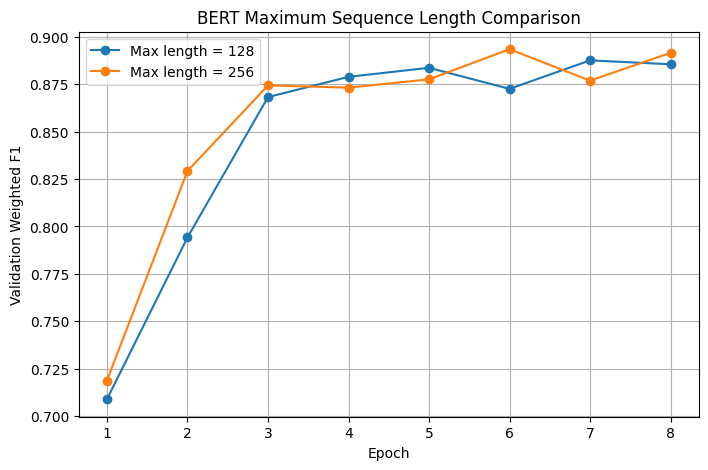

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for max_length in MAX_LENGTHS:
    history_df = max_length_histories[max_length]

    plt.plot(
        history_df["epoch"],
        history_df["validation_weighted_f1"],
        marker="o",
        label=f"Max length = {max_length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Weighted F1")
plt.title("BERT Maximum Sequence Length Comparison")
plt.legend()
plt.grid(True)
plt.show()

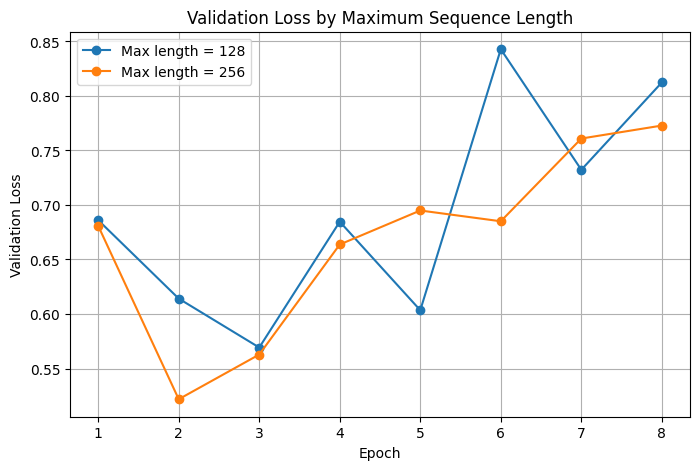

In [71]:
plt.figure(figsize=(8, 5))

for max_length in MAX_LENGTHS:
    history_df = max_length_histories[max_length]

    plt.plot(
        history_df["epoch"],
        history_df["validation_loss"],
        marker="o",
        label=f"Max length = {max_length}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss by Maximum Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

# **Compare the batch size 8 vs 16**

In [72]:
import copy
import gc
import random
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, Subset
from transformers import BertForSequenceClassification


SEED = 9444

BATCH_SIZES = [8, 16]

LEARNING_RATE = 2e-5
MAX_LENGTH = 256
MAX_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 2
NUM_LABELS = 3
VALIDATION_RATIO = 0.20


def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


reset_seed()

print("Device:", device)
print("Training samples:", len(train_df))

Device: cuda
Training samples: 5159


In [73]:
sentences = train_df["sentence"].astype(str).tolist()

labels = torch.tensor(
    train_df["label"].astype(int).tolist(),
    dtype=torch.long
)

batch_size_encodings = tokenizer(
    sentences,
    add_special_tokens=True,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_attention_mask=True,
    return_tensors="pt"
)

full_batch_size_dataset = TensorDataset(
    batch_size_encodings["input_ids"],
    batch_size_encodings["attention_mask"],
    labels
)

print(
    "Encoded shape:",
    batch_size_encodings["input_ids"].shape
)

Encoded shape: torch.Size([5159, 256])


In [74]:
num_samples = len(full_batch_size_dataset)

split_generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    num_samples,
    generator=split_generator
).tolist()

validation_size = int(
    num_samples * VALIDATION_RATIO
)

training_size = (
    num_samples - validation_size
)

validation_indices = indices[:validation_size]
training_indices = indices[validation_size:]

training_dataset = Subset(
    full_batch_size_dataset,
    training_indices
)

validation_dataset = Subset(
    full_batch_size_dataset,
    validation_indices
)

print("Training size:", len(training_dataset))
print("Validation size:", len(validation_dataset))

Training size: 4128
Validation size: 1031


In [75]:
def evaluate_batch_size_model(
    model,
    data_loader,
    device
):
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in data_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = (
        total_loss / len(data_loader)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1
    }

In [76]:
def train_batch_size_experiment(
    batch_size,
    training_dataset,
    validation_dataset,
    device,
    learning_rate=2e-5,
    max_epochs=8,
    patience=2
):
    print("\n" + "=" * 75)
    print(
        f"Starting BATCH_SIZE experiment: {batch_size}"
    )
    print("=" * 75)

    reset_seed()

    train_loader = DataLoader(
        training_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = (
        BertForSequenceClassification
        .from_pretrained(
            MODEL_NAME,
            num_labels=NUM_LABELS
        )
    )

    model.to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_f1 = -1.0
    best_epoch = 0
    best_model_state = None

    epochs_without_improvement = 0
    history = []

    experiment_start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()

        total_train_loss = 0.0

        for (
            input_ids,
            attention_mask,
            labels
        ) in train_loader:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_train_loss += loss.item()

        average_train_loss = (
            total_train_loss / len(train_loader)
        )

        validation_metrics = (
            evaluate_batch_size_model(
                model,
                validation_loader,
                device
            )
        )

        history.append({
            "batch_size": batch_size,
            "epoch": epoch,
            "train_loss": average_train_loss,
            "validation_loss":
                validation_metrics["loss"],
            "validation_accuracy":
                validation_metrics["accuracy"],
            "validation_weighted_f1":
                validation_metrics["weighted_f1"],
            "validation_macro_f1":
                validation_metrics["macro_f1"]
        })

        print(
            f"Batch {batch_size:>2} | "
            f"Epoch {epoch:02d} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: "
            f"{validation_metrics['loss']:.4f} | "
            f"Val Accuracy: "
            f"{validation_metrics['accuracy']:.4f} | "
            f"Val Weighted F1: "
            f"{validation_metrics['weighted_f1']:.4f} | "
            f"Val Macro F1: "
            f"{validation_metrics['macro_f1']:.4f}"
        )

        current_f1 = (
            validation_metrics["weighted_f1"]
        )

        if current_f1 > best_validation_f1:
            best_validation_f1 = current_f1
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= patience
            ):
                print(
                    f"Early stopping for "
                    f"BATCH_SIZE={batch_size} "
                    f"after epoch {epoch}."
                )
                break

    elapsed_seconds = (
        time.time() - experiment_start
    )

    model.load_state_dict(
        best_model_state
    )

    best_metrics = (
        evaluate_batch_size_model(
            model,
            validation_loader,
            device
        )
    )

    result = {
        "Batch Size": batch_size,
        "Learning Rate": learning_rate,
        "Max Length": MAX_LENGTH,
        "Best Epoch": best_epoch,
        "Best Validation Loss":
            best_metrics["loss"],
        "Best Validation Accuracy":
            best_metrics["accuracy"],
        "Best Validation Weighted F1":
            best_metrics["weighted_f1"],
        "Best Validation Macro F1":
            best_metrics["macro_f1"],
        "Training Time Minutes":
            elapsed_seconds / 60
    }

    history_df = pd.DataFrame(history)

    del train_loader
    del validation_loader
    del optimizer
    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        result,
        history_df,
        best_model_state
    )

In [77]:
batch_size_results = []
batch_size_histories = {}
batch_size_checkpoints = {}

for batch_size in BATCH_SIZES:
    (
        result,
        history_df,
        best_model_state
    ) = train_batch_size_experiment(
        batch_size=batch_size,
        training_dataset=training_dataset,
        validation_dataset=validation_dataset,
        device=device,
        learning_rate=LEARNING_RATE,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE
    )

    batch_size_results.append(result)

    batch_size_histories[
        batch_size
    ] = history_df

    batch_size_checkpoints[
        batch_size
    ] = best_model_state


Starting BATCH_SIZE experiment: 8


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batch  8 | Epoch 01 | Train Loss: 0.9069 | Val Loss: 0.6808 | Val Accuracy: 0.7168 | Val Weighted F1: 0.7188 | Val Macro F1: 0.7053
Batch  8 | Epoch 02 | Train Loss: 0.4861 | Val Loss: 0.5219 | Val Accuracy: 0.8283 | Val Weighted F1: 0.8292 | Val Macro F1: 0.8227
Batch  8 | Epoch 03 | Train Loss: 0.2357 | Val Loss: 0.5629 | Val Accuracy: 0.8739 | Val Weighted F1: 0.8743 | Val Macro F1: 0.8684
Batch  8 | Epoch 04 | Train Loss: 0.1383 | Val Loss: 0.6638 | Val Accuracy: 0.8729 | Val Weighted F1: 0.8732 | Val Macro F1: 0.8657
Batch  8 | Epoch 05 | Train Loss: 0.1097 | Val Loss: 0.6949 | Val Accuracy: 0.8778 | Val Weighted F1: 0.8775 | Val Macro F1: 0.8718
Batch  8 | Epoch 06 | Train Loss: 0.0692 | Val Loss: 0.6851 | Val Accuracy: 0.8923 | Val Weighted F1: 0.8934 | Val Macro F1: 0.8882
Batch  8 | Epoch 07 | Train Loss: 0.0738 | Val Loss: 0.7609 | Val Accuracy: 0.8778 | Val Weighted F1: 0.8769 | Val Macro F1: 0.8674
Batch  8 | Epoch 08 | Train Loss: 0.0723 | Val Loss: 0.7728 | Val Accuracy: 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batch 16 | Epoch 01 | Train Loss: 0.9354 | Val Loss: 0.8278 | Val Accuracy: 0.6023 | Val Weighted F1: 0.5691 | Val Macro F1: 0.5477
Batch 16 | Epoch 02 | Train Loss: 0.5239 | Val Loss: 0.5777 | Val Accuracy: 0.7837 | Val Weighted F1: 0.7870 | Val Macro F1: 0.7798
Batch 16 | Epoch 03 | Train Loss: 0.2567 | Val Loss: 0.5377 | Val Accuracy: 0.8565 | Val Weighted F1: 0.8568 | Val Macro F1: 0.8496
Batch 16 | Epoch 04 | Train Loss: 0.1534 | Val Loss: 0.6107 | Val Accuracy: 0.8623 | Val Weighted F1: 0.8617 | Val Macro F1: 0.8558
Batch 16 | Epoch 05 | Train Loss: 0.0984 | Val Loss: 0.6955 | Val Accuracy: 0.8584 | Val Weighted F1: 0.8579 | Val Macro F1: 0.8512
Batch 16 | Epoch 06 | Train Loss: 0.0857 | Val Loss: 0.6436 | Val Accuracy: 0.8885 | Val Weighted F1: 0.8878 | Val Macro F1: 0.8834
Batch 16 | Epoch 07 | Train Loss: 0.0728 | Val Loss: 0.6408 | Val Accuracy: 0.8807 | Val Weighted F1: 0.8818 | Val Macro F1: 0.8742
Batch 16 | Epoch 08 | Train Loss: 0.0481 | Val Loss: 0.7342 | Val Accuracy: 

In [78]:
batch_size_results_df = pd.DataFrame(
    batch_size_results
).sort_values(
    by="Best Validation Weighted F1",
    ascending=False
).reset_index(drop=True)

display(batch_size_results_df)

,Batch Size,Learning Rate,Max Length,Best Epoch,Best Validation Loss,Best Validation Accuracy,Best Validation Weighted F1,Best Validation Macro F1,Training Time Minutes
0,8,0.00002,256,6,0.685050,0.892338,0.893413,0.888159,27.838371
1,16,0.00002,256,6,0.643567,0.888458,0.887758,0.883367,25.630152


In [79]:
best_batch_size = int(
    batch_size_results_df
    .iloc[0]["Batch Size"]
)

best_batch_f1 = (
    batch_size_results_df
    .iloc[0]["Best Validation Weighted F1"]
)

print(
    "Best batch size:",
    best_batch_size
)

print(
    "Best validation weighted F1:",
    best_batch_f1
)

Best batch size: 8
Best validation weighted F1: 0.8934132237263113


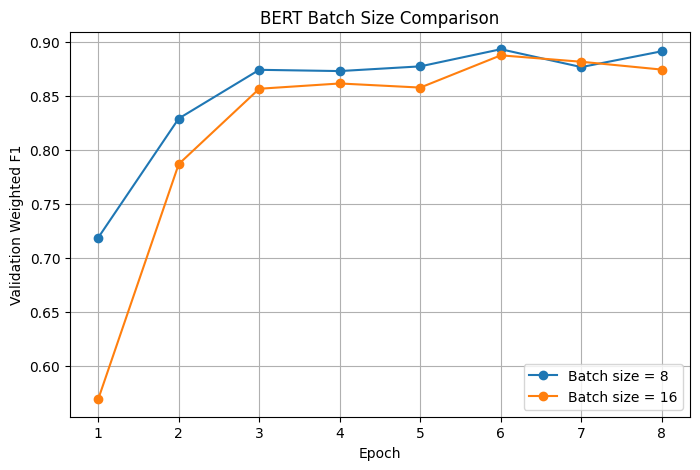

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for batch_size in BATCH_SIZES:
    history_df = (
        batch_size_histories[
            batch_size
        ]
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            "validation_weighted_f1"
        ],
        marker="o",
        label=(
            f"Batch size = {batch_size}"
        )
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Weighted F1")
plt.title(
    "BERT Batch Size Comparison"
)
plt.legend()
plt.grid(True)
plt.show()

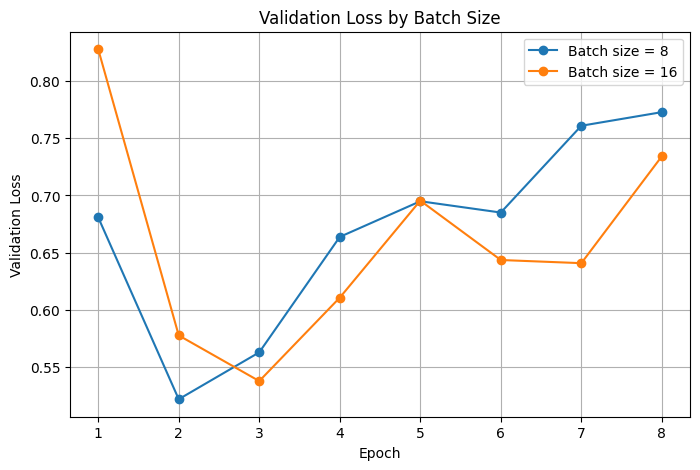

In [81]:
plt.figure(figsize=(8, 5))

for batch_size in BATCH_SIZES:
    history_df = (
        batch_size_histories[
            batch_size
        ]
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            "validation_loss"
        ],
        marker="o",
        label=(
            f"Batch size = {batch_size}"
        )
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss by Batch Size"
)
plt.legend()
plt.grid(True)
plt.show()

In [83]:
batch_size_results_df.to_csv(
    "/kaggle/working/"
    "batch_size_comparison.csv",
    index=False
)

for batch_size in BATCH_SIZES:
    batch_size_histories[
        batch_size
    ].to_csv(
        f"/kaggle/working/"
        f"batch_size_{batch_size}_history.csv",
        index=False
    )

    torch.save(
        batch_size_checkpoints[
            batch_size
        ],
        f"/kaggle/working/"
        f"batch_size_{batch_size}_best_model.pt"
    )

print("Batch-size results saved.")

Batch-size results saved.
